In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import sys
import json
from pathlib import Path

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils.tools import aggregate_results

In [112]:
def get_suite(row):

    n_demos = row["number of demonstrations"]
    type_demos = row["type of demonstrations"][0:3]
    instr = "impl" if row["use instructions"] == "no" else "expl"

    return f"{n_demos}-{type_demos}-{instr}"

def order_models(strings, rev=False):
    return sorted(strings, key=lambda s: (
        s.split('-')[0],  # Model name
        -1 * int(s.split('-')[1][:-1]),  # Param count, B dropped
    ), reverse=rev)

def capitalize(s):
    return s[0].upper() + s[1:]

In [113]:
def barchart(df, metric_cols):

    df = aggregate_results(res, ["model"], metric_cols, funs=["mean", "std"])
    df.columns = [" ".join(list(cols)).replace(" mean ", " ") for cols in df.columns]
    df = df.reset_index()

    # Assume your dataframe is called df
    models = df['model'].values

    # Means
    theme_mean = df['theme f1 mean'].values
    topic_mean = df['topic f1 mean'].values
    concept_mean = df['concept f1 mean'].values

    # Standard deviations
    theme_std = df['theme f1 std'].values
    topic_std = df['topic f1 std'].values
    concept_std = df['concept f1 std'].values

    # X positions
    x = np.arange(len(models))
    width = 0.25  # width of bars

    # Create plot
    fig = plt.figure()

    plt.bar(x - width, theme_mean, width, yerr=theme_std, capsize=4, label='Theme F1')
    plt.bar(x,         topic_mean, width, yerr=topic_std, capsize=4, label='Topic F1')
    plt.bar(x + width, concept_mean, width, yerr=concept_std, capsize=4, label='Concept F1')

    # Labels & formatting
    plt.xticks(x, models, rotation=45)
    plt.ylabel('F1 Score')
    plt.xlabel('Model')
    plt.title('F1 Scores by Model (with Std Dev)')
    plt.legend()

    plt.tight_layout()

    return fig

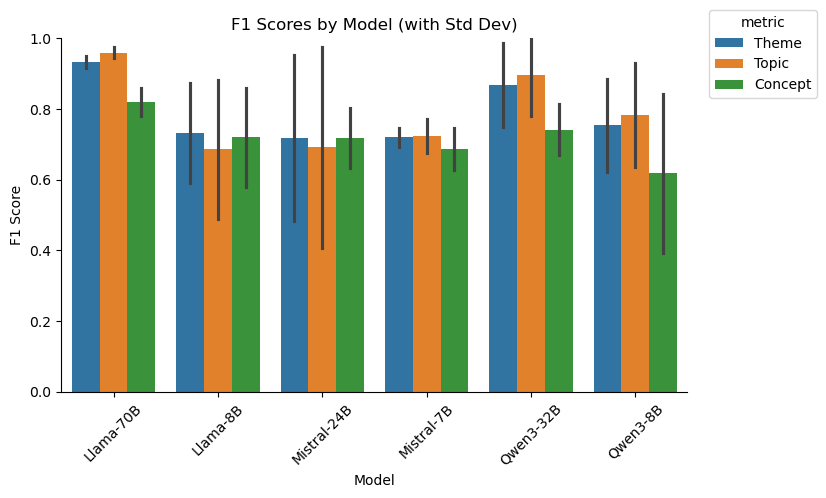

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def barchart_sns(df, metric_cols, kind="box"): 
    # Convert to long format
    plot_df = pd.DataFrame({
        'model': df['model'].tolist() * 3,
        'metric': (['Theme'] * len(df) +
                   ['Topic'] * len(df) +
                   ['Concept'] * len(df)),
        'mean': pd.concat([df[col] for col in metric_cols_f1], ignore_index=True)
    })

    g = sns.catplot(
        data=plot_df,
        order=order_models(res["model"].unique()),
        x='model',
        y='mean',
        hue='metric',
        kind=kind,
        errorbar="sd", height=5, aspect=1.2,
    )

    # Labels & formatting
    sns.move_legend(g, "upper left", frameon=True, bbox_to_anchor=(1, 1))
    g.set_axis_labels("Model", "F1 Score")
    g.set(ylim=(0, 1))
    plt.title('F1 Scores by Model (with Std Dev)')
    plt.xticks(rotation=45)

    #plt.legend()
    plt.tight_layout()

    return g

#fig = barchart_sns(res, metric_cols_f1, kind="box")

fig = barchart_sns(res, metric_cols_f1, kind="bar")
#plt.savefig("./latex/images/f1_per_model_sns.png")
#res

In [4]:
metric_cols_f1 = ["theme f1 mean", "topic f1 mean", "concept f1 mean"]
metric_cols_prec = ["theme precision mean", "topic precision mean", "concept precision mean"]
metric_cols_rec = ["theme recall mean", "topic recall mean", "concept recall mean"]

res = pd.read_csv("./data/metrics.csv", sep=";")
res = res.sort_values(by=["use instructions", "number of demonstrations", "type of demonstrations"])
res["suite"] = res.apply(get_suite, axis=1)

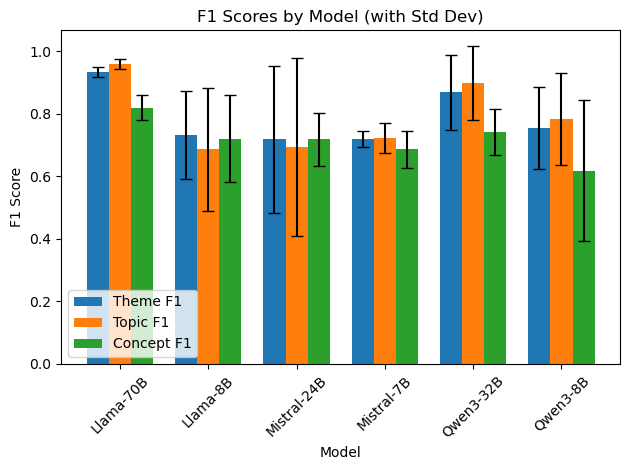

In [5]:
fig = barchart(res, metric_cols_f1)

#plt.savefig("./latex/images/f1_per_model.png")
plt.show()